## Imports

In [3]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from mypackages.eRDF import *
from mypackages.edp_processing import peak_calibration
from mypackages.plot_style import set_plot_style

set_plot_style()


In [5]:
pd.read_csv(f1)

,# source=iq_average.csv
q,fq
0.9933703946810645,0.11414210776380074
1.0062713088977016,0.08759013162673668
1.019172223114339,0.06274072134144149
1.0320731373309762,0.03653453066069745
...,...
17.93227076112571,-0.15671577521557367
17.945171675342348,-0.050377032486199624
17.958072589558984,-0.18226852641921454
17.97097350377562,0.12377577527610484


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

f1 = Path(r"Z:\ActualWork\Victor\processed_data\ePDF\Fe3O4\fe3o4_2nm\20251007\average\fq_iq_average.csv")
f2 = Path(r"Z:\ActualWork\Victor\processed_data\ePDF\Fe3O4\fe3o4_2nm\20250925\fq_iq_average.csv")

q = pd.read_csv(f1, skiprows=1)["q"].values
fq = pd.read_csv(f1, skiprows=1)["fq"].values

q1 = pd.read_csv(f2, skiprows=1)["q"].values
fq1 = pd.read_csv(f2, skiprows=1)["fq"].values

plt.figure(figsize =(15,6))
plt.plot(q, fq)
plt.plot(q1, fq1)

plt.xlim(0, 20)

plt.xlabel('r (Å)')
plt.ylabel('G(r)')

plt.tight_layout()
plt.show()


KeyError: 'q'

In [1]:
0.029994*10

0.29994

In [5]:
import math

0.0192471154893000/(2*math.pi)

0.0030632735703826786

In [6]:
f2 = Path(r"Z:\ActualWork\Victor\processed_data\ePDF\Fe3O4\fe3o4_2nm\20250827\gr_fe3o4_4nm_exp1s_spot4_spirit.csv")


r = pd.read_csv(f2)["r"].values
gr = pd.read_csv(f2)["gr"].values

In [7]:
pd.DataFrame(np.array([r, gr]).T).to_csv(f2.parent / "gr_fe3o4_4nm_spirit.csv", header=False, index=False)

In [93]:
from scipy.signal import savgol_filter
import numpy as np

# fqs: (n_profiles, n_points)
# fq: averaged profile
# q: x-axis

# baselines
filt_fqs = savgol_filter(fqs, 13, 2, axis=-1, mode='interp')
filt_fq  = savgol_filter(fq, 13, 2, axis=-1, mode='interp')

# residuals
rs  = fqs - filt_fqs
r_avg = fq - filt_fq

# robust noise estimates
mad_profiles = np.median(np.abs(rs - np.median(rs, axis=1, keepdims=True)), axis=1) / 0.6745
mad_avg      = np.median(np.abs(r_avg - np.median(r_avg))) / 0.6745

# signal: peak height relative to baseline
A_profiles = np.max(fqs - filt_fqs, axis=1)
A_avg      = np.max(fq  - filt_fq)

# SNR per profile and for the average
snr_profiles = A_profiles / mad_profiles
snr_avg      = A_avg / mad_avg

improvement = snr_avg / np.mean(snr_profiles)
improvement


np.float64(0.872165632581831)

In [96]:
snr_profiles

array([10.97969985, 10.4693168 , 12.11364924])

In [ ]:
def merged_functions(q, params):
    f1 = params["P_E11"] * np.exp(-params["P_E12"] * q)
    f2 = params["P_E21"] * np.exp(-params["P_E22"] * q)
    f3 = params["P_E31"] * np.exp(-params["P_E32"] * q)
    f4 = params["P_B_0"]  # P_B_1 and P_B_2 assumed zero

    merged = f1 + f2 + f3 + f4
    return q, merged

nm4 = {
    "P_E11": 1633438.7,
    "P_E12": 0.82652294,
    "P_E21": 228244.81,
    "P_E22": 2.1458741,
    "P_E31": 170987.07,
    "P_E32": 3.8367678,
    "P_B_0": 27234.804,
}

s6 = {
    "P_E11": 3002495.1,
    "P_E12": 0.50205325,
    "P_E21": 1972609.8,
    "P_E22": 0.99450414,
    "P_E31": 476500.02,
    "P_E32": 2.9561441,
    "P_B_0": 30769.929,
}

in2o3 = {
    "P_E11": 1267639.4,
    "P_E12": 0.59280668,
    "P_E21": 788875.63,
    "P_E22": 1.4155007,
    "P_E31": 590987.84,
    "P_E32": 3.0938410,
    "P_B_0": 250140.78,
}




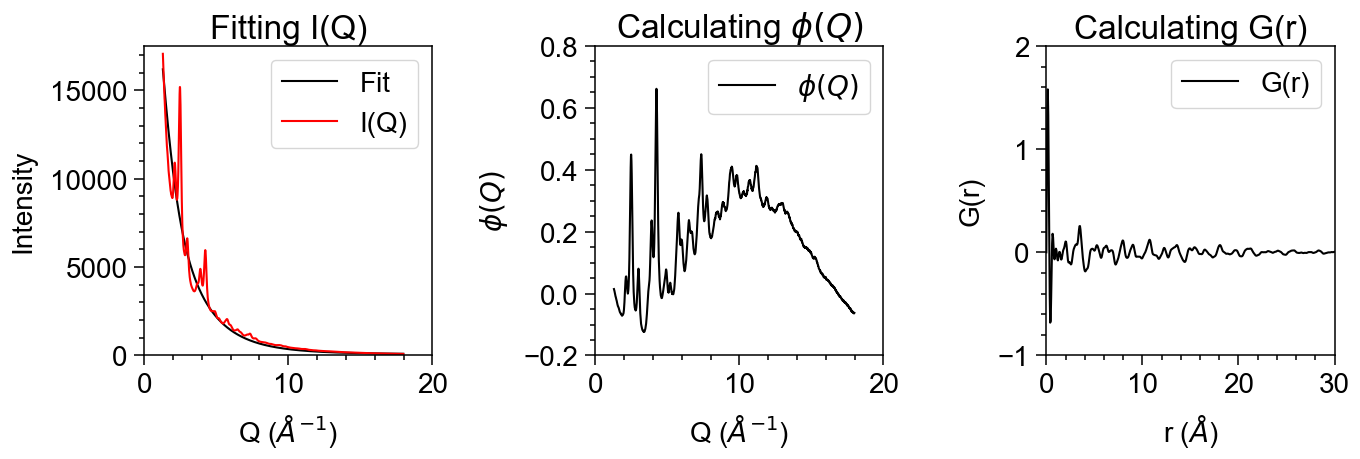

The q max is:17.98 and the qmin:1.30 


In [99]:
from mypackages.eRDF import *

proc = DataProcessor()

start_name = r"Z:\ActualWork\Victor\processed_data\ePDF\Fe3O4\fe3o4_6nm\iq_iq_average.csv"

df1 = pd.read_csv(start_name, header=None, skiprows=3)

ds = (df1[0].values[1] - df1[0].values[0])/(2*math.pi) #AuNPs


start = 2
# data = df1.sum(axis=1)[start:]
data = df1[1].values

CdSe =  {1: [30, 1], 2: [8, 1],}
Magnetite = {'Fe': [26, 3], 'O': [8, 4],}
Au = {'Au': [79, 1],}

# qmin must the superior to qmax
q0 = df1[0].values[0]
qmin = 1.3
qmax = 19

start = int((qmin - q0) / (ds * 2 * math.pi))
end = int((qmax - q0) / (ds * 2 * math.pi))
end = min(end, len(data))


# 1) data & q-grid
x, iq, q, s, s2 = proc.load_and_process_data(
    data= data,   # 1D I(Q_pixel) or similar
    start= start,
    end= end,
    ds= ds,           # Δq per pixel / (2π) if following your formula
    q0= q0
)

# 2) element factors from Lobato
proc.Elements = Magnetite        # e.g. {"Cd":[rowidx, count], "Se":[rowidx, count]}
lob = proc.Lobato_Factors()            # uses proc.Elements, proc.s2, proc.x

# 3) weighted moments
fbar_sq, mean_f2, fbar_sq_ref, iq_ref = proc.compute_weighted_factors()

# 5) normalization/background fit
N, C, autofit = proc.N_and_parameters(region = 0)
proc.N, proc.C, proc.autofit = N, C, autofit


sq, fq = proc.sq_fq(iq, damping=0.3)
r, Gr = proc.Gr(fq, rmax=80, dr=0.05)

proc.plot_results(fq, r, Gr0=Gr)

qmax_out = float(q.max())
qmin_out = float(q.min())
print(f"The q max is:{qmax_out:.2f} and the qmin:{qmin_out:.2f} ")

Index near 2.4: 87  q= 2.401618402379377  autofit= 851473.153837327  iq= 1328704.7749023438
Index near 18: 1308  q= 17.999363451875222  autofit= 9358.61437467431  iq= 8971.857999349724
autofit ratio (18/2.4): 329.73256992887866
iq ratio (18/2.4): 54.01866942193615


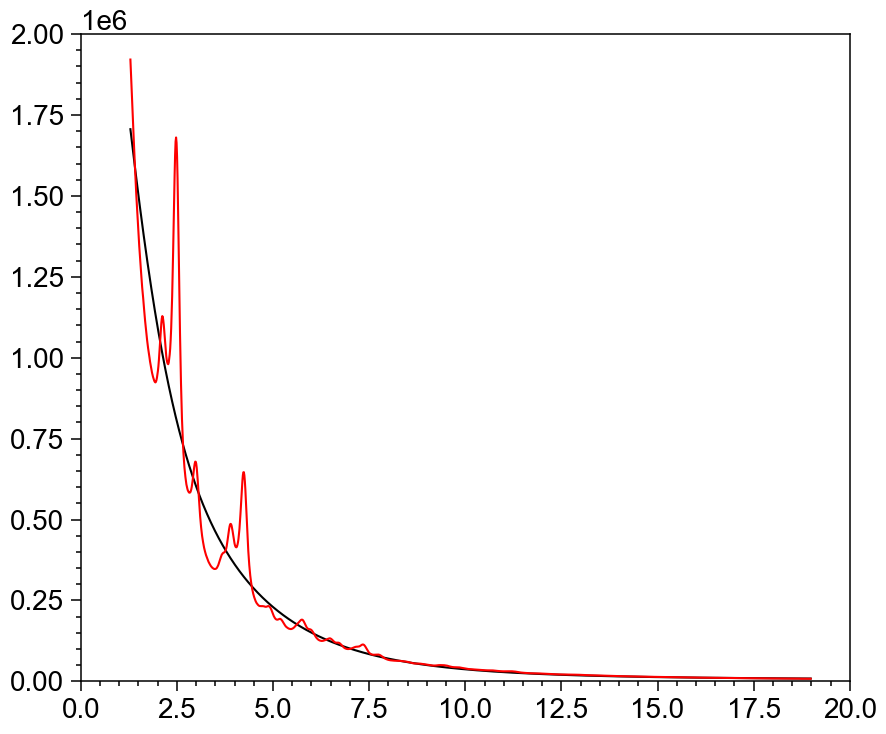

In [18]:
plt.plot(q, proc.autofit)
plt.plot(q, iq)

i1 = np.argmin(np.abs(q - 2.4))
i2 = np.argmin(np.abs(q - 18))

print("Index near 2.4:", i1, " q=", q[i1], " autofit=", proc.autofit[i1], " iq=", iq[i1])
print("Index near 18:", i2, " q=", q[i2], " autofit=", proc.autofit[i2], " iq=", iq[i2])

ratio_autofit = proc.autofit[i2] / proc.autofit[i1]
ratio_iq = iq[i2] / iq[i1]

print("autofit ratio (18/2.4):", 30000*ratio_autofit)
print("iq ratio (18/2.4):", 8000*ratio_iq)



## Polynomial fitting

In [100]:
degree = 8
rmax = 80
dr = 0.01

norm_autofit = (proc.iq / (proc.autofit)) * proc.q
norm_N = (proc.iq / (proc.N * proc.fbar_sq)) * proc.q

cs1 = np.polyfit(proc.q, norm_autofit, degree)
cs2 = np.polyfit(proc.q, norm_N, 8)

p1 = np.poly1d(cs1)
p2 = np.poly1d(cs2)

y_fit1 = p1(proc.q)
y_fit2 = p2(proc.q)

fq_poly1 = norm_autofit - y_fit1
fq_poly2 = norm_N - y_fit2

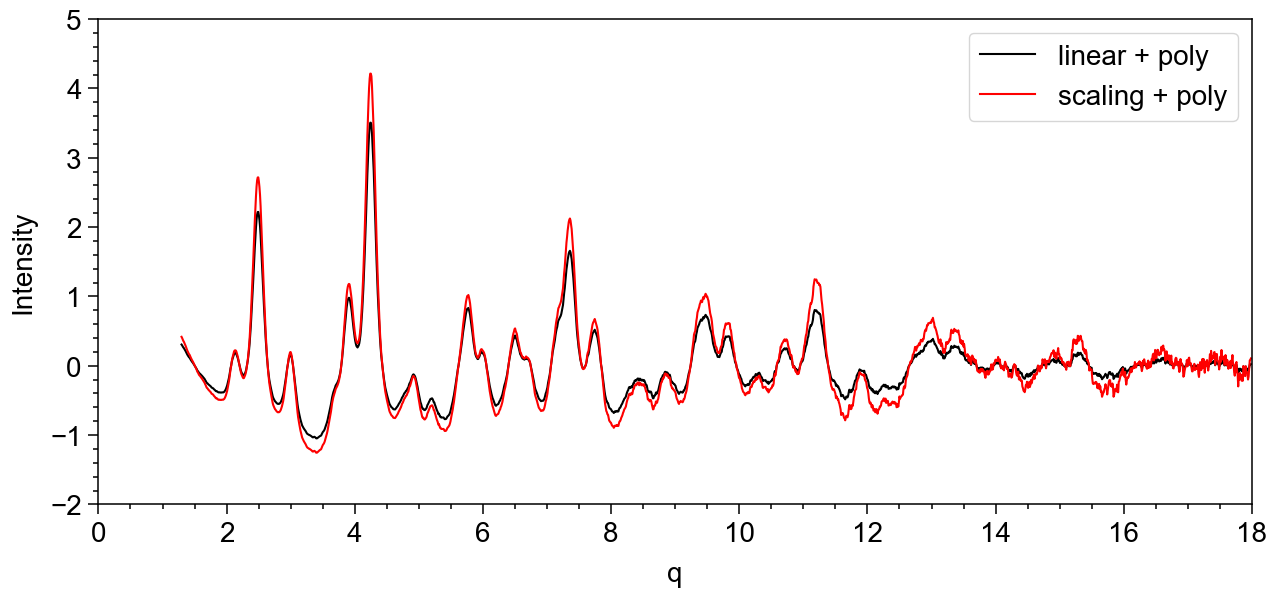

In [101]:
plt.figure(figsize = (15,6))

plt.plot(q, fq_poly1, label = "linear + poly")
plt.plot(q, fq_poly2, label = "scaling + poly")

plt.legend()
plt.xlabel("q")
plt.ylabel("Intensity")
plt.show()


(0.0, 50.0)

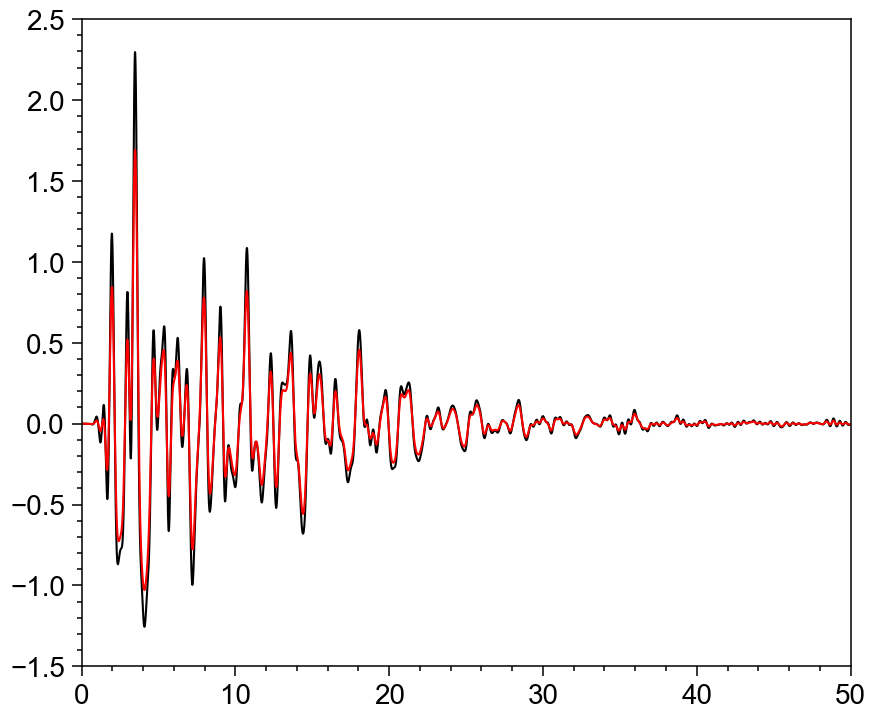

In [85]:
r, Gr_1 = proc.Gr(fq_poly1, rmax=100, dr=0.01)
r, Gr_2 = proc.Gr(fq_poly2, rmax=100, dr=0.01)

plt.plot(r, Gr_2)
plt.plot(r, Gr_1)
plt.xlim(0, 50)

## G(r) calculation

In [122]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mypackages.eRDF import Gr, read_discus_fit_file


# Calculate G(r) from F(Q)
r_raw, Gr_raw = Gr(dp1.q, fq_poly, rmax=100, dr=0.01)

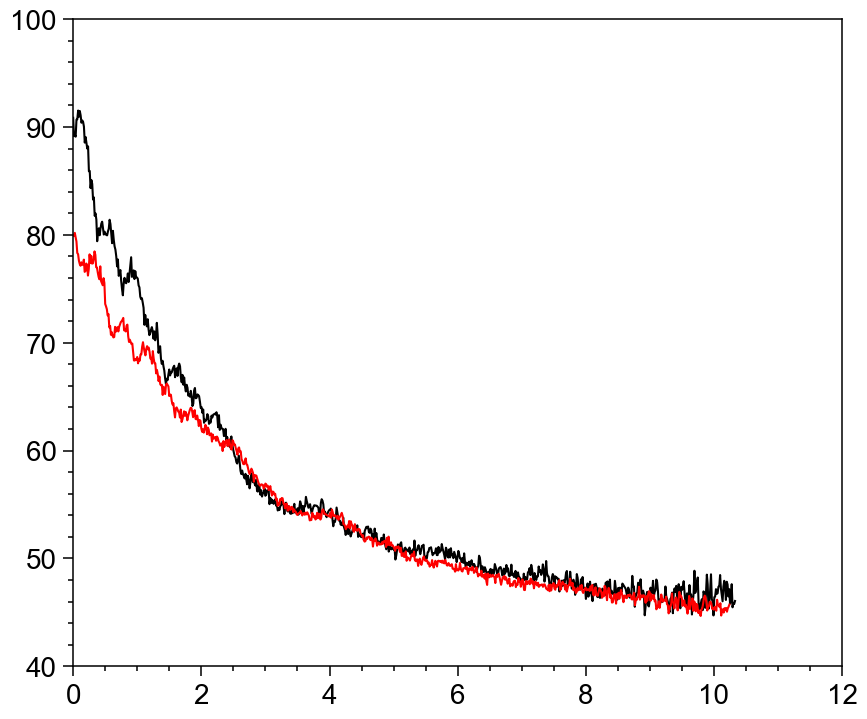

In [86]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

p = r"C:\Users\seccolev\data_processing\data\processed\ePDF\In2O3\20250822\in2o3_exp10s_spot6_f30.csv"
q = r"C:\Users\seccolev\data_processing\data\processed\ePDF\In2O3\20250815\in2o3_exp1s_spot2_f30.csv"

f30 =    pd.read_csv(p, header=None, skiprows = 1)
spirit = pd.read_csv(q, header=None, skiprows = 1)

iqf30 = f30[1].values[600:1400]
iqspirit = spirit[0].values[600:1400]

x = np.arange(0, len(iqf30)*0.012926118827172666,  0.012926118827172666)
x2 = np.arange(0, len(iqf30)*0.012816757013383256,  0.012816757013383256)

plt.plot(x, iqf30)
plt.plot(x2, iqspirit)

# plt.xlim(0,1400)
plt.show()


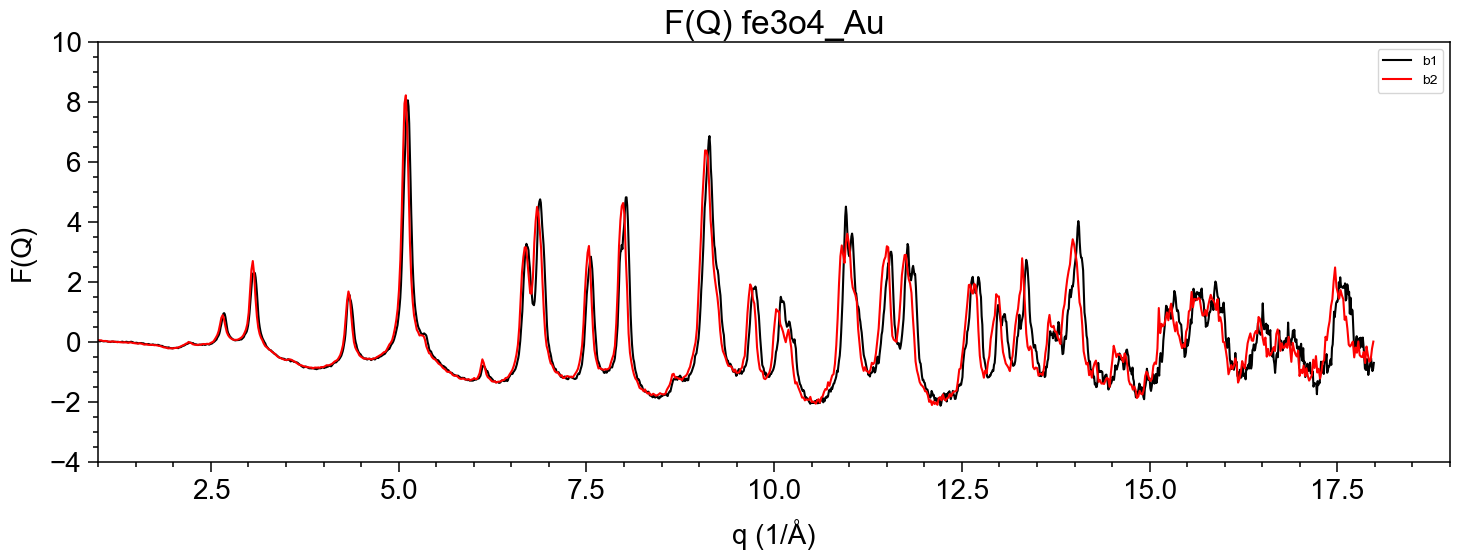

In [ ]:
# Plot
plt.figure(figsize=(15, 6))

# F(Q)
plt.plot(qb1, fqb1, label='b1')
plt.plot(dp1.q, fq_poly, label='b2')
plt.xlim(1, 19)
plt.xlabel('q (1/Å)')
plt.ylabel('F(Q)')
plt.title('F(Q) fe3o4_Au')
plt.legend(fontsize=10)

# G(r)
# axs[1].plot(r_raw, Gr_raw, label='G(r) from F(Q)')
# axs[1].set_xlim(0, 60)
# axs[1].set_xlabel('r (Å)')
# axs[1].set_ylabel('G(r)')
# axs[1].set_title('G(r) fe3o4_2nm')
# axs[1].legend(fontsize=10)


plt.tight_layout()
plt.show()

# output_path = os.path.dirname(start_name)
# pd.DataFrame(np.array([dp1.q, fq_poly]).T, columns = ["q", "fq"]).to_csv(os.path.join(output_path, "fq_fe3o4_exp1s_spot4_spirit.csv"), sep="\t", index=None, )

In [ ]:
import numpy as np
from scipy.integrate import quad, simpson
from scipy.interpolate import InterpolatedUnivariateSpline

def G_int_callable(G, upper=np.inf, limit=500, epsabs=1e-10, epsrel=1e-8):
    val, err = quad(lambda r: r * G(r), 0.0, upper, limit=limit, epsabs=epsabs, epsrel=epsrel)
    return val, err

def G_int_arrays(r, G, method="auto"):
    r = np.asarray(r, dtype=float)
    G = np.asarray(G, dtype=float)
    y = r * G
    if method == "auto":
        if (len(r) % 2 == 1) and np.allclose(np.diff(np.diff(r)), 0):
            return simpson(y, x=r, even="last")
        return np.trapz(y, r)
    if method == "simpson":
        return simpson(y, x=r, even="last")
    if method == "trapz":
        return np.trapz(y, r)
    raise ValueError("method must be 'auto', 'simpson', or 'trapz'")

def G_int_from_sampled_callable(r, G, k=3):
    spl = InterpolatedUnivariateSpline(r, G, k=k, ext=1)
    return quad(lambda x: x * spl(x), 0.0, r[-1])[0]


In [ ]:
import numpy as np

def integrate_rG(r, G, rmin=None, rmax=None, method="trapz"):
    r = np.asarray(r, float)
    G = np.asarray(G, float)
    m = np.isfinite(r) & np.isfinite(G)
    if rmin is not None:
        m &= r >= rmin
    if rmax is not None:
        m &= r <= rmax
    r = r[m]
    y = r * G[m]
    if method == "trapz":
        return np.trapz(y, r)
    elif method == "simpson":
        from scipy.integrate import simpson
        return simpson(y, x=r, even="last")
    else:
        raise ValueError("method must be 'trapz' or 'simpson'")

G_int_total = integrate_rG(r_raw, Gr_raw*5)
r_cut = 100.0
G_int_0_R = integrate_rG(r_raw, Gr_raw, rmax=r_cut)

print("G_int total:", G_int_total)
print(f"G_int [0, {r_cut}]:", G_int_0_R)


G_int total: -0.9724988608333401
G_int [0, 100.0]: -0.12071248880410196


C:\Users\seccolev\AppData\Local\Temp\ipykernel_22376\2522659068.py:14: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(y, r)


## G(r) Lorch calculation

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mypackages.eRDF import Gr, calc_Gr_Lorch

# Parameters
rmax = 200
dr = 0.05

# Compute G(r) with and without Lorch window
r_lorch, Gr_lorch = calc_Gr_Lorch(q, fq, rmax=rmax, dr=dr, rmin=0, transition_width=5)
r_raw, Gr_raw = Gr(q, fq, rmax=rmax, dr=dr)

xmin = 0 
xmax = 2500

# Plot comparison
plt.figure(figsize=(16, 5))
plt.plot(r_raw[xmin:xmax], Gr_raw[xmin:xmax], label='G(r) raw', alpha=0.8)
plt.plot(r_lorch[xmin:xmax], Gr_lorch[xmin:xmax], label='G(r) with Lorch', alpha=0.9)
plt.xlabel('r (Å)')
plt.ylabel('G(r)')
plt.xlim(0,100)
plt.title('Comparison of G(r) with and without Lorch Window')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## EnvACS exporting

In [ ]:
import os

output_path = os.path.dirname(input_path_gr)

pd.DataFrame([r_raw,Gr_raw], index=None).T.to_csv(os.path.join(output_path, "Gr_CdSe_P5_EnvACS.csv"), index=None)

In [284]:
pd.read_csv(f, skiprows =  0)

,# source=b1_1s_250.csv
0,q\tiq
1,0.9951354742115993\t35540.037841796875
2,1.004265157461247\t34872.070068359375
3,1.0133948407108948\t34247.043212890625
4,1.0225245239605425\t33736.125
...,...
1858,17.94895726880738\t315.1152902698283
1859,17.958086952057027\t315.90646304881375
1860,17.967216635306674\t316.53015006821283
1861,17.97634631855632\t314.7316407316407


In [321]:
pd.read_csv(f)

,# source=b2_1s_250.csv
0,q\tfq
1,0.9826706174967667\t0.10214791769028153
2,1.0008682215244846\t0.08021526268975121
3,1.0190658255522023\t0.06464645630840926
4,1.0372634295799203\t0.062460482096667436
...,...
931,17.906442363274415\t-0.6865123848362913
932,17.924639967302134\t-0.14947124664985978
933,17.942837571329846\t-0.4208334803185281
934,17.961035175357566\t-0.6440831480615117


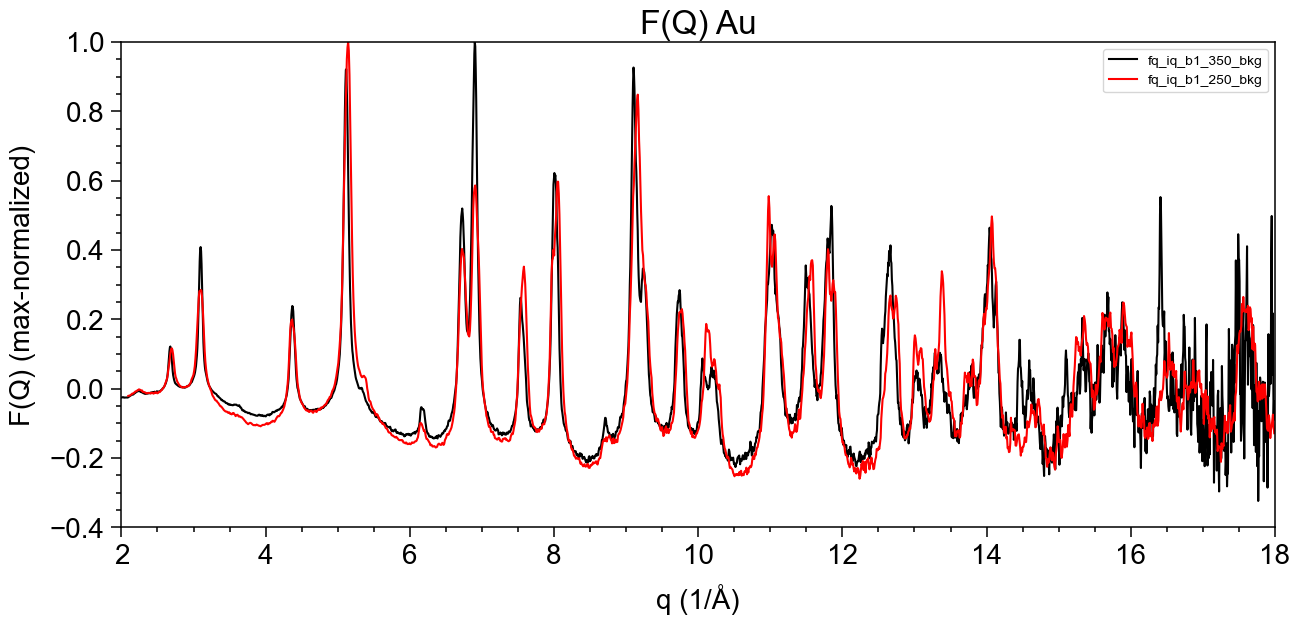

In [381]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

p = Path(r"Z:\ActualWork\Victor\processed_data\ePDF\Au\20250910\fq_gr")
files = [x for x in p.iterdir() if (x.is_file() and 'b1' in x.name and 'bkg' in x.name and x.name.startswith("fq"))]

plt.figure(figsize=(15,6))

for f in files[::-1]:
    df = pd.read_csv(f, skiprows=1, usecols=["q","fq"])
    q = df["q"].values[120:]
    fq = df["fq"].values[120:]
    m = np.nanmax(np.abs(fq))
    if not np.isfinite(m) or m == 0:
        continue
    fq = fq / m
    plt.plot(q, fq, label=f.stem)

plt.xlim(2, 18)
plt.xlabel('q (1/Å)')
plt.ylabel('F(Q) (max-normalized)')
plt.title('F(Q) Au')
plt.legend(fontsize=10)
plt.show()


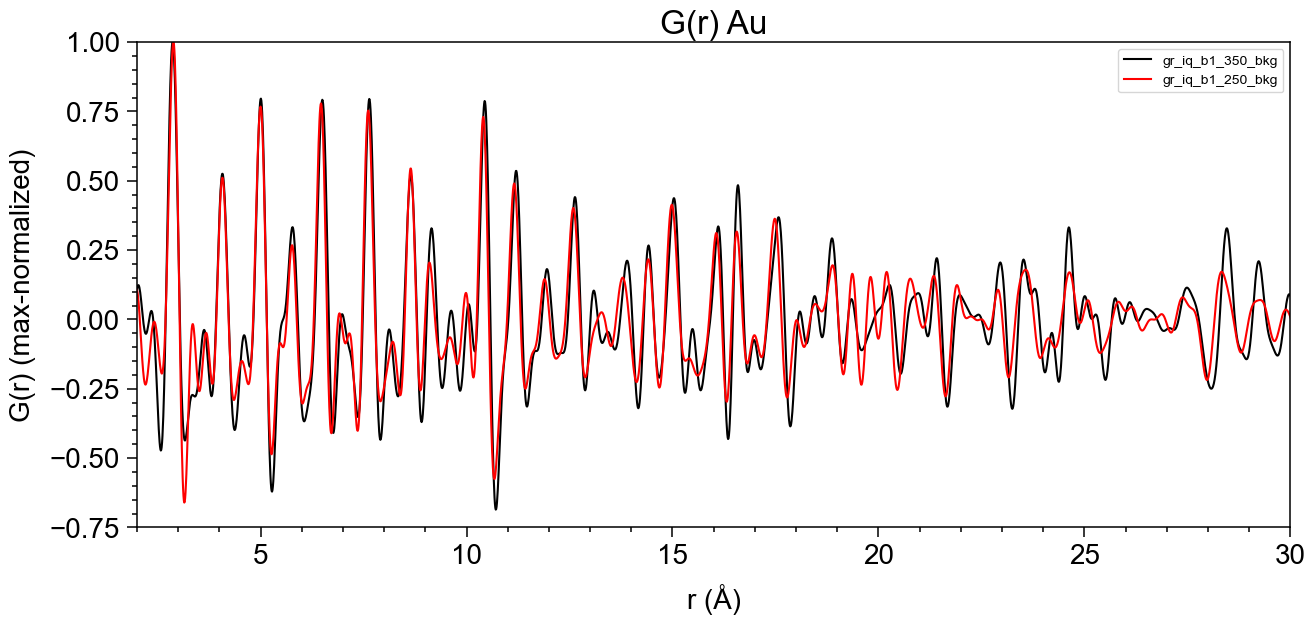

In [380]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

p = Path(r"Z:\ActualWork\Victor\processed_data\ePDF\Au\20250910\fq_gr")
files = [x for x in p.iterdir() if (x.is_file() and 'b1' in x.name and 'bkg' in x.name and x.name.startswith("gr"))]

plt.figure(figsize=(15,6))

for f in files[::-1]:
    df = pd.read_csv(f, skiprows=1, usecols=["r", "Gr"])
    r = df["r"].values[120:]
    gr = df["Gr"].values[120:]
    m = np.nanmax(np.abs(gr))
    if not np.isfinite(m) or m == 0:
        continue
    gr = gr / m
    plt.plot(r, gr, label=f.stem)

plt.xlim(2,30)
plt.xlabel('r (Å)')
plt.ylabel('G(r) (max-normalized)')
plt.title('G(r) Au')
plt.legend(fontsize=10)
plt.show()


C:\Users\seccolev\AppData\Local\Temp\ipykernel_25276\3135759817.py:41: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integrated_intensity = np.trapz(yfit, x)
C:\Users\seccolev\AppData\Local\Temp\ipykernel_25276\3135759817.py:41: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integrated_intensity = np.trapz(yfit, x)


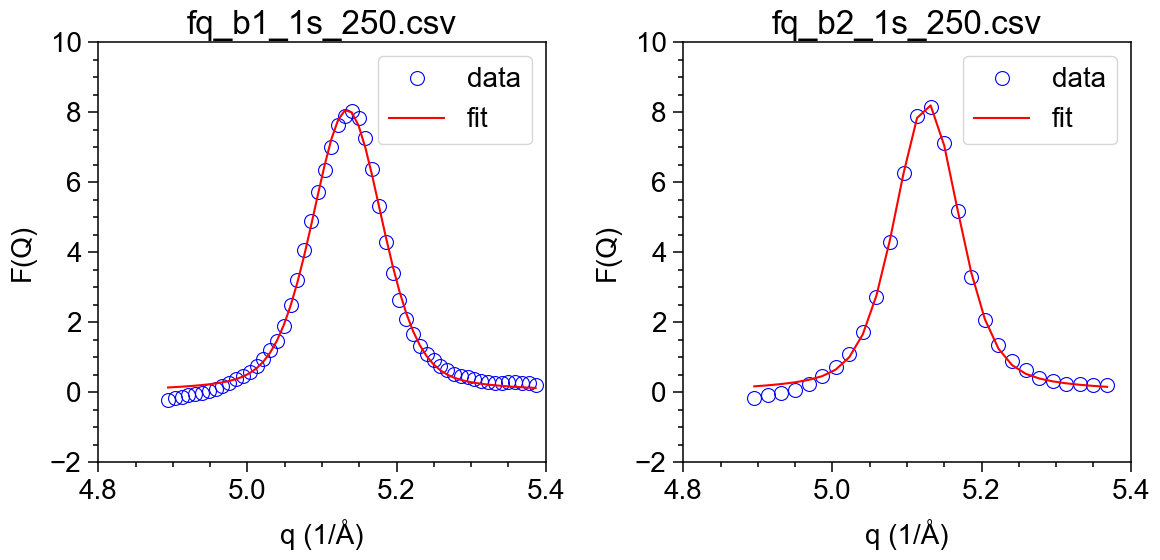

fq_b1_1s_250.csv | q_peak=5.1400  FWHM=0.112408  Height=8.060423  Area=1.052771
fq_b2_1s_250.csv | q_peak=5.1317  FWHM=0.103704  Height=8.198179  Area=1.021498


In [359]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from lmfit.models import PseudoVoigtModel
from scipy.signal import find_peaks

p = Path(r"Z:\ActualWork\Victor\processed_data\ePDF\Au\20250910\fq_gr")
files = [x for x in p.iterdir() if (x.is_file() and '250' in x.name and x.name.startswith("fq"))]
files = sorted(files)[:2]

results = []

plt.figure(figsize=(12,6))

for i, f in enumerate(files, 1):
    df = pd.read_csv(f, skiprows=1, usecols=["q","fq"])
    q = df["q"].values[120:]
    fq = df["fq"].values[120:]
    peaks, props = find_peaks(fq, height=3)
    if peaks.size == 0:
        print(f"{f.name}: no peaks found")
        continue

    q0 = q[peaks][0]
    mask = (q >= q0 - 0.25) & (q <= q0 + 0.25)
    x = q[mask]
    y = fq[mask]
    if x.size < 5:
        print(f"{f.name}: insufficient points around the first peak")
        continue

    mod = PseudoVoigtModel()
    pars = mod.guess(y, x=x)
    out = mod.fit(y, pars, x=x)
    yfit = mod.eval(out.params, x=x)

    fwhm = out.params["fwhm"].value
    peak_height = float(yfit.max())
    # integrated intensity: area under fitted curve
    integrated_intensity = np.trapz(yfit, x)

    results.append((f.name, q0, fwhm, peak_height, integrated_intensity))

    plt.subplot(1,2,i)
    plt.plot(x, y, "bo", label="data")
    plt.plot(x, yfit, "r-", label="fit")
    plt.title(f.name)
    plt.xlabel("q (1/Å)")
    plt.ylabel("F(Q)")
    plt.legend()

plt.tight_layout()
plt.show()

for name, q0, fwhm, peak_height, integrated_intensity in results:
    print(f"{name} | q_peak={q0:.4f}  FWHM={fwhm:.6f}  Height={peak_height:.6f}  Area={integrated_intensity:.6f}")


## discus data handling